### Baseline Model

Based on the EDA.ipynb we can safely start with a baseline of a yes/no (Binary Classification) model
- Goal: Binary Classifier that answers chest X-ray questions with "Yes or "No"
- Input: Image and Question Text
- Output: Probability of yes or no

- Architecture: CNN (image), frozen DistilBERT CLS token (text) then feed it into a Classifier

**Engineering Logic and Reasoning:** Solve the simpler, well-defined binary problem first, measure it cleanly, then expand to closed-vocabulary

#### Using Colab therefore need to pip install the packages 

### Pip install and Imports

In [8]:
!pip install -q wandb grad-cam

In [9]:
import os
import yaml
import random
from dataclasses import dataclass, field # This should minimize spaghetti code 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

import wandb

### Configuration cell

In [10]:
@dataclass
class ModelConfig:
    """Architecture Decisions"""
    text_model_id: str = "distilbert-base-uncased"
    img_size: int = 224
    max_text_len: int = 32
    text_emb_dim: int = 768 # distilBert hidden size

@dataclass
class TrainingConfig:
    """Hyperparameters"""
    wandb_project: str = "vqa_chest"
    run_name: str = "baseline_cnn_bert_yesno"
    dataset: str = "flaviagiammarino/vqa-rad"
    batch_size: int = 16
    lr: float = 1e-3
    epochs: int = 10
    seed: int = 42
    checkpoint_dir: str = "models"
    predictions_dir: str = "predictions"

model_cfg = ModelConfig()
training_cfg = TrainingConfig()

# Just to be safe
os.makedirs(training_cfg.checkpoint_dir, exist_ok=True)
os.makedirs(training_cfg.predictions_dir, exist_ok=True)

### Weights and Biases API Key

In [ ]:
wandb.login(key="BLANK")
print("W&B authenticated")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ganadilynaif (naif-mayo-clinic) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B authenticated


### Reproducibility and Device

In [14]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(training_cfg.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


Filter to yes/no answers only and map labels: `no to 0`, `yes to 1`


In [15]:
label_map = {"yes": 1, "no": 0}

def is_yes_no(example) -> bool:
    return example["answer"].lower() in label_map

def add_label(example) -> dict:
    return {"label": label_map[example["answer"].lower()]}


ds = load_dataset(training_cfg.dataset)

train_yn = ds["train"].filter(is_yes_no).map(add_label)
test_yn  = ds["test"].filter(is_yes_no).map(add_label)

train_labels = [ex["label"] for ex in train_yn]
test_labels  = [ex["label"] for ex in test_yn]

print(f"Train : {len(train_yn):>4}  |  yes: {sum(train_labels)/len(train_labels):.1%}")
print(f"Test  : {len(test_yn):>4}  |  yes: {sum(test_labels)/len(test_labels):.1%}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Train :  940  |  yes: 49.7%
Test  :  251  |  yes: 47.0%


Based on EDA
- Widths cluster roughly around 500–600 px and around 1000 px, with a few very large outliers
- Heights cluster around 400–800 px, with some up to around 1400 px

for the Baseline 224x224 is a standard size used by most CNNs such as ResNet

Downsizing from larger radiology images may:
- Loses some fine detail but for first experiments it is common to keep the compute cheap by keeping it to 224x224

We could be more careful by adding a CenterCrop

In [16]:
# Img_tranform with CenterCrop, ReSize and Normalize
# Because the images are of different sizes, we need to resize them to a fixed size before feeding them to the model
# We can use CenterCrop to crop the center of the image and then resize it to 224x224
# Then we can normalize the images using the mean and std of the ImageNet dataset
img_transform = transforms.Compose([
    transforms.Resize(512),
    transforms.CenterCrop(512),
    transforms.Resize((model_cfg.img_size, model_cfg.img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

### Text Encoder Frozen DistilBert

In [17]:
tokenizer  = AutoTokenizer.from_pretrained(model_cfg.text_model_id)
text_model = AutoModel.from_pretrained(model_cfg.text_model_id)
text_model.eval()

for param in text_model.parameters():
    param.requires_grad = False

print(f"Loaded & frozen: {model_cfg.text_model_id}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded & frozen: distilbert-base-uncased


### Question Encoder 

As a standalone function reused by VQARADBinaryDataset and predict(). Outside the class to avoid duplicating tokernizer/model references 

In [18]:
def encode_question(question: str) -> torch.Tensor:
    """Returns DistilBERT CLS-token embedding. Shape: [text_emb_dim]"""
    inputs = tokenizer(
        question,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=model_cfg.max_text_len,
    )
    with torch.no_grad():
        outputs = text_model(**inputs)
    return outputs.last_hidden_state[0, 0]   # [768]

In [19]:
class VQARADBinaryDataset(Dataset):
    def __init__(self, hf_split, img_transform):
        self.data          = hf_split
        self.img_transform = img_transform

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx):
        ex = self.data[idx]
        return (
            self.img_transform(ex["image"]), # [3, 224, 224]
            encode_question(ex["question"]), # [768]
            ex["label"], # 0 or 1
        )


# Checking the dataset
_img, _emb, _lbl = VQARADBinaryDataset(train_yn, img_transform)[0]
print(f"Image: {_img.shape} | Text emb: {_emb.shape} | Label: {_lbl}")

Image: torch.Size([3, 224, 224]) | Text emb: torch.Size([768]) | Label: 1


### Dataloaders

In [20]:
train_dataset = VQARADBinaryDataset(train_yn, img_transform)
test_dataset  = VQARADBinaryDataset(test_yn,  img_transform)

train_loader = DataLoader(train_dataset, batch_size=training_cfg.batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=training_cfg.batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

Train batches: 59 | Test batches: 16


| Branch | Output shape |
|---|---|
| CNN (2× Conv to ReLU to MaxPool) | `[B, 32, 56, 56]` to flatten to `[B, 100352]` |
| DistilBERT CLS token | `[B, 768]` |
| Fused to classifier | `[B, 256]` to `[B, 1]` |

In [21]:
class ImageTextBinaryModel(nn.Module):

    # Named constant — not a magic number (Clean Code G25)
    CNN_OUTPUT_DIM = 32 * 56 * 56   # 2× MaxPool2d on 224×224 input

    def __init__(self, text_emb_dim: int = model_cfg.text_emb_dim):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(3,  16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(self.CNN_OUTPUT_DIM + text_emb_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 1),
        )

    def forward(self, images: torch.Tensor, text_embs: torch.Tensor) -> torch.Tensor:
        """images: [B,3,224,224]  text_embs: [B,768]  →  logits: [B]"""
        img_features  = self.cnn(images).flatten(1)
        fused         = torch.cat([img_features, text_embs], dim=1)
        return self.classifier(fused).squeeze(1)


model     = ImageTextBinaryModel().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=training_cfg.lr)

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 25,892,321


Training Loop

Logs train/loss and train/accuracy to W&B per epoch

In [22]:
wandb.init(
    project=training_cfg.wandb_project,
    name=training_cfg.run_name,
    config={**vars(model_cfg), **vars(training_cfg)},
)

train_losses, train_accs = [], []

for epoch in range(1, training_cfg.epochs + 1):
    model.train()
    running_loss = correct = total = 0

    for images, text_embs, labels in train_loader:
        images    = images.to(device)
        text_embs = text_embs.to(device)
        labels    = labels.float().to(device)

        optimizer.zero_grad()
        logits = model(images, text_embs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(logits) > 0.5).long()
        correct += (preds.cpu() == labels.cpu().long()).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    wandb.log({"epoch": epoch, "train/loss": epoch_loss, "train/accuracy": epoch_acc})
    print(f"Epoch {epoch:02d}/{training_cfg.epochs}  loss={epoch_loss:.4f}  acc={epoch_acc:.4f}")

wandb.finish()

Epoch 01/10  loss=1.0897  acc=0.5851
Epoch 02/10  loss=0.5289  acc=0.7372
Epoch 03/10  loss=0.4538  acc=0.7872
Epoch 04/10  loss=0.4234  acc=0.8160
Epoch 05/10  loss=0.4183  acc=0.8160
Epoch 06/10  loss=0.3824  acc=0.8181
Epoch 07/10  loss=0.3758  acc=0.8245
Epoch 08/10  loss=0.3557  acc=0.8245
Epoch 09/10  loss=0.3286  acc=0.8426
Epoch 10/10  loss=0.3226  acc=0.8553


epoch,▁▂▃▃▄▅▆▆▇█
train/accuracy,▁▅▆▇▇▇▇▇██
train/loss,█▃▂▂▂▂▁▁▁▁
epoch,10
train/accuracy,0.85532
train/loss,0.32263


### Training Curves

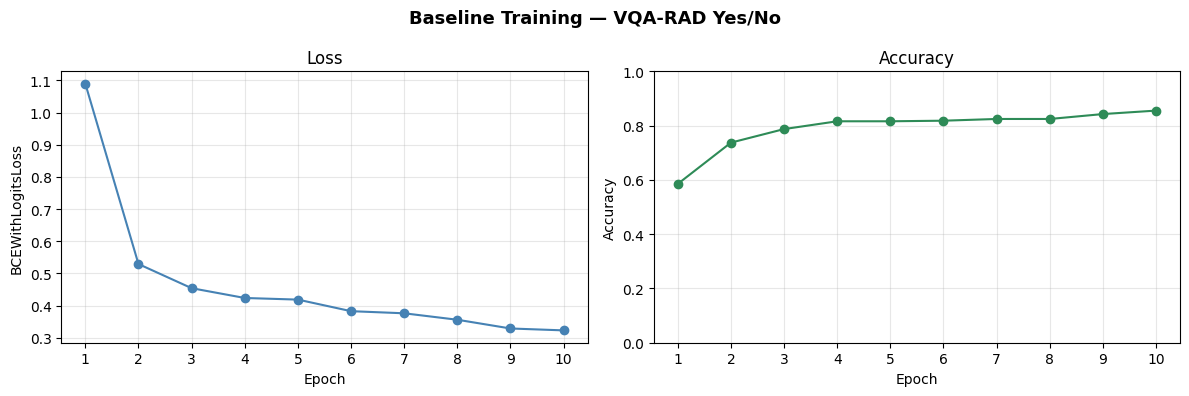

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Baseline Training — VQA-RAD Yes/No", fontsize=13, fontweight="bold")
epochs = range(1, len(train_losses) + 1)

ax1.plot(epochs, train_losses, "o-", color="steelblue")
ax1.set(title="Loss", xlabel="Epoch", ylabel="BCEWithLogitsLoss")
ax1.set_xticks(epochs); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, train_accs, "o-", color="seagreen")
ax2.set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
ax2.set_xticks(epochs); ax2.set_ylim(0, 1); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

Evaluation collecting all the predictions

In [24]:
model.eval()
all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for images, text_embs, labels in test_loader:
        probs = torch.sigmoid(model(images.to(device), text_embs.to(device))).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        all_labels.extend(labels.numpy())
        all_preds.extend(preds)
        all_probs.extend(probs)

auc_roc = roc_auc_score(all_labels, all_probs)
avg_p   = average_precision_score(all_labels, all_probs)
acc     = sum(p == t for p, t in zip(all_preds, all_labels)) / len(all_labels)

print(classification_report(all_labels, all_preds, target_names=["No", "Yes"]))
print(f"AUC-ROC : {auc_roc:.4f}")
print(f"Avg Prec: {avg_p:.4f}")
print(f"Accuracy: {acc:.4f}")

wandb.init(
    project=training_cfg.wandb_project,
    name=f"{training_cfg.run_name}_eval",
    config={**vars(model_cfg), **vars(training_cfg)},
)
wandb.log({"test/accuracy": acc, "test/auc_roc": auc_roc, "test/avg_precision": avg_p})
wandb.finish()

              precision    recall  f1-score   support

          No       0.65      0.56      0.60       133
         Yes       0.57      0.66      0.61       118

    accuracy                           0.61       251
   macro avg       0.61      0.61      0.61       251
weighted avg       0.61      0.61      0.61       251

AUC-ROC : 0.6511
Avg Prec: 0.6045
Accuracy: 0.6056


test/accuracy,▁
test/auc_roc,▁
test/avg_precision,▁
test/accuracy,0.60558
test/auc_roc,0.65108
test/avg_precision,0.60454


Confusion Matrix

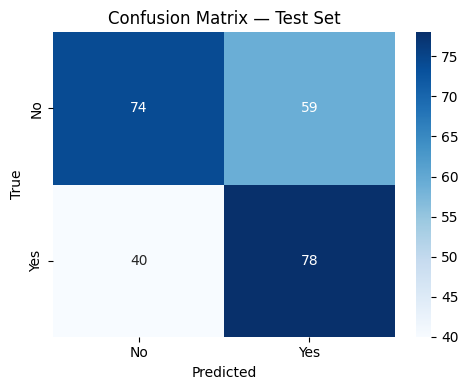

In [25]:
plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion_matrix(all_labels, all_preds),
    annot=True, fmt="d", cmap="Blues",
    xticklabels=["No", "Yes"], yticklabels=["No", "Yes"],
)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout(); plt.show()

ROC and PR Curves

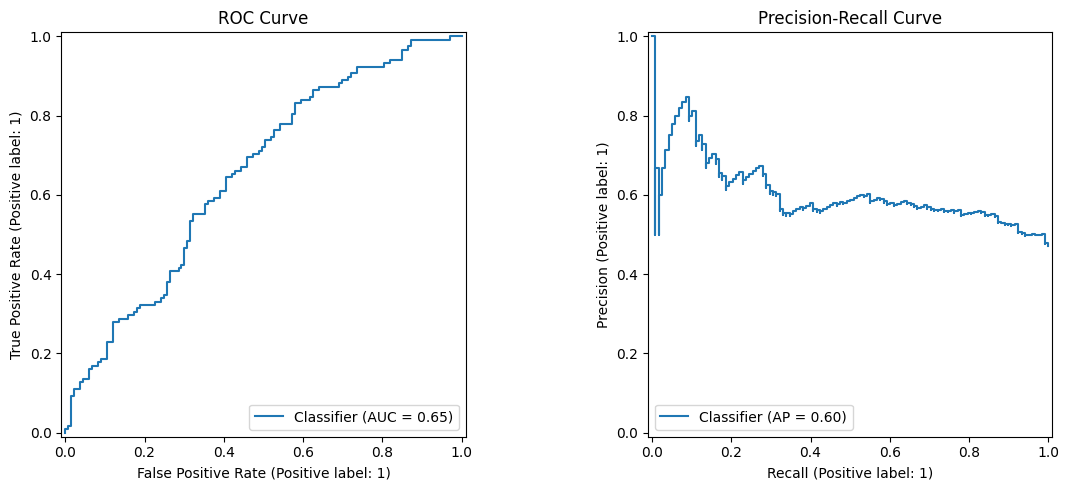

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(all_labels, all_probs, ax=ax1)
PrecisionRecallDisplay.from_predictions(all_labels, all_probs, ax=ax2)
ax1.set_title("ROC Curve")
ax2.set_title("Precision-Recall Curve")
plt.tight_layout(); plt.show()

Confidence Distribution

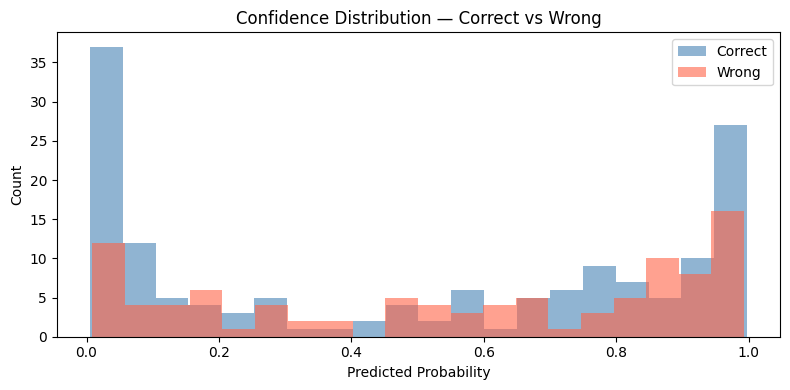

In [27]:
correct_probs = [p for p, t, pr in zip(all_probs, all_labels, all_preds) if t == pr]
wrong_probs   = [p for p, t, pr in zip(all_probs, all_labels, all_preds) if t != pr]

plt.figure(figsize=(8, 4))
plt.hist(correct_probs, bins=20, alpha=0.6, label="Correct", color="steelblue")
plt.hist(wrong_probs,   bins=20, alpha=0.6, label="Wrong",   color="tomato")
plt.xlabel("Predicted Probability"); plt.ylabel("Count")
plt.title("Confidence Distribution — Correct vs Wrong")
plt.legend(); plt.tight_layout(); plt.show()

Error Analysis

In [28]:
errors = [
    (i, true, pred, prob)
    for i, (true, pred, prob) in enumerate(zip(all_labels, all_preds, all_probs))
    if true != pred
]

print(f"Total errors: {len(errors)} / {len(all_labels)}\n")
for idx, true, pred, prob in errors[:5]:
    ex = test_yn[idx]
    print(f"Q: {ex['question']}")
    print(f"   True: {'Yes' if true else 'No'}  |  Pred: {'Yes' if pred else 'No'}  |  Conf: {prob:.3f}\n")

Total errors: 99 / 251

Q: is there evidence of an aortic aneurysm?
   True: Yes  |  Pred: No  |  Conf: 0.008

Q: is there airspace consolidation on the left side?
   True: Yes  |  Pred: No  |  Conf: 0.079

Q: is there any intraparenchymal abnormalities in the lung fields?
   True: No  |  Pred: Yes  |  Conf: 0.758

Q: are the kidneys present in this image?
   True: No  |  Pred: Yes  |  Conf: 0.696

Q: is the liver visible in the image?
   True: No  |  Pred: Yes  |  Conf: 0.882



### Gradcam Interpretability

ImageTextWarpper adapts the fusion model for GradCAM which expects a single tensor input. The text embeddings are fixed from the current batch

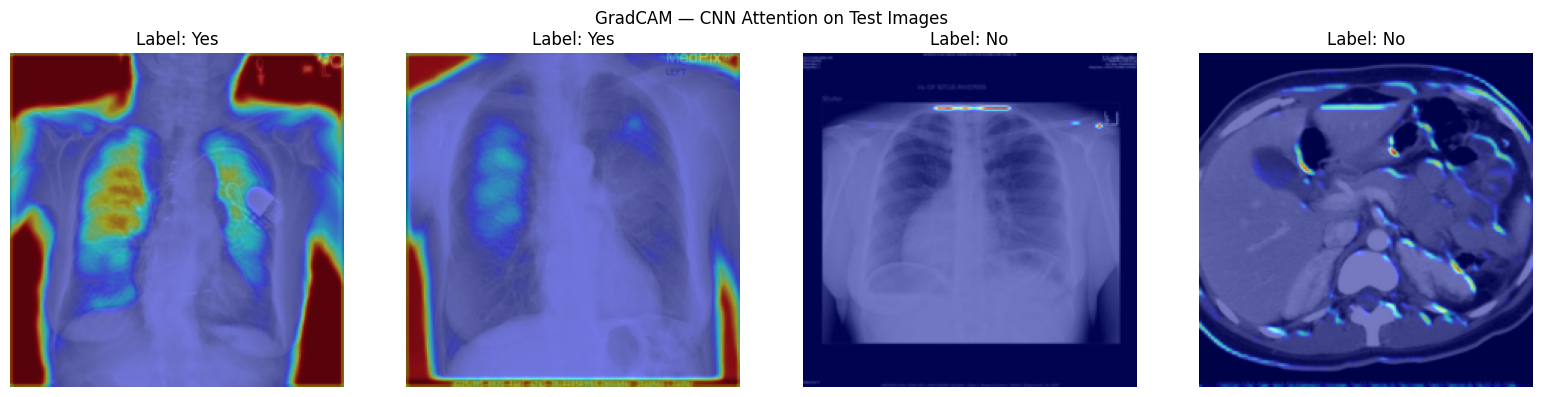

In [30]:
class BinaryOutputTarget:
    """GradCAM target for binary classifiers that output a single logit per sample."""
    def __call__(self, model_output: torch.Tensor) -> torch.Tensor:
        return model_output  # already a scalar — no indexing needed


model.eval()
images, text_embs, labels = next(iter(test_loader))
images, text_embs = images.to(device), text_embs.to(device)

wrapped        = _ImageTextWrapper(model, text_embs)
cam            = GradCAM(model=wrapped, target_layers=[model.cnn[-3]])
grayscale_cams = cam(
    input_tensor=images,
    targets=[BinaryOutputTarget()] * images.size(0),  # ← fixed
)

n_examples = 4
fig, axes  = plt.subplots(1, n_examples, figsize=(4 * n_examples, 4))

for i, ax in enumerate(axes):
    img_np = images[i].cpu().numpy().transpose(1, 2, 0)
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
    vis    = show_cam_on_image(img_np, grayscale_cams[i], use_rgb=True)
    ax.imshow(vis); ax.axis("off")
    ax.set_title(f"Label: {'Yes' if labels[i].item() else 'No'}")

plt.suptitle("GradCAM — CNN Attention on Test Images")
plt.tight_layout(); plt.show()

### Single Example Inference

`predict()` takes only what it uniquely needs — `model`, `image`, `question`.
Everything else (`tokenizer`, `text_model`, `img_transform`, `device`) lives in
notebook scope and is accessed directly

In [31]:
def predict(model: nn.Module, image, question: str, threshold: float = 0.5) -> tuple:
    """Returns (answer: str, confidence: float) for one image+question pair."""
    model.eval()
    img_tensor = img_transform(image).unsqueeze(0).to(device)
    text_emb   = encode_question(question).unsqueeze(0).to(device)
    with torch.no_grad():
        prob = torch.sigmoid(model(img_tensor, text_emb)).item()
    return ("yes" if prob >= threshold else "no"), round(prob, 3)


# Demo
example            = test_yn[0]
answer, confidence = predict(model, example["image"], example["question"])
print(f"Q: {example['question']}")
print(f"A (predicted):    {answer}  (confidence: {confidence})")
print(f"A (ground truth): {example['answer']}")

Q: is there evidence of an aortic aneurysm?
A (predicted):    no  (confidence: 0.008)
A (ground truth): yes


In [34]:
checkpoint_path  = os.path.join(training_cfg.checkpoint_dir,  "baseline_image_text_binary.pt")
predictions_path = os.path.join(training_cfg.predictions_dir, "baseline_test_predictions.csv")

torch.save(model.state_dict(), checkpoint_path)
print(f"Model saved to {checkpoint_path}")

pd.DataFrame({
    "true_label": all_labels,
    "predicted": all_preds,
    "probability": all_probs,
}).to_csv(predictions_path, index=False)
print(f"Predictions saved to {predictions_path}")

Model saved to models/baseline_image_text_binary.pt
Predictions saved to predictions/baseline_test_predictions.csv


In [35]:
checkpoint_path = os.path.join(training_cfg.checkpoint_dir, "baseline_image_text_binary.pt")

model = ImageTextBinaryModel().to(device)
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

print(f"Loaded from: {checkpoint_path}")
print(f"Parameters : {sum(p.numel() for p in model.parameters()):,}")

Loaded from: models/baseline_image_text_binary.pt
Parameters : 25,892,321
